# 兩頻道 Shorts 分析模板（template_two）

適用情境：類別有 2 個頻道（如遊戲、籃球幹片、籃球網紅、Kpop）。
核心檢定：Mann-Whitney U；OLS 含 0/1 channel dummy。

## 0. 參數

In [1]:
# === 參數區 ===========================================================
# 改類別只要改這三行；下方所有 cell 都引用這些變數
CSV_TIMESTAMP = "20260527-064831"      # 改這裡切換不同類別的資料
TARGET_CHANNELS = None                  # None = 全部；或填 list 過濾特定頻道
CATEGORY_NAME = "遊戲"               # 用於圖表標題、檔名
# ====================================================================


## 1. 匯入函式庫

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文字體（macOS 預設沒有 Microsoft 系列，使用 sans-serif 後備）
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 將 _templates/ 加入 sys.path 以便 import content_labeling
TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))

print("✓ 函式庫載入完成")


✓ 函式庫載入完成


## 2. 載入 CSV

In [3]:
# 載入資料（路徑從 analysis/<cat>/ 回退兩層到 final project/）
df = pd.read_csv(f'../../data/processed/channel_videos_{CSV_TIMESTAMP}.csv', encoding='utf-8')
df_channels = pd.read_csv(f'../../data/processed/channels_{CSV_TIMESTAMP}.csv', encoding='utf-8')

if TARGET_CHANNELS is not None:
    df = df[df['channel_title'].isin(TARGET_CHANNELS)].copy()

print(f"✓ 資料載入：{len(df)} 列影片 / {len(df_channels)} 列頻道")
print(f"頻道：{df['channel_title'].unique().tolist()}")


✓ 資料載入：400 列影片 / 2 列頻道
頻道：['camman18', 'GothamChess']


## 3. 檢視資料結構

In [4]:
print(df.dtypes)
print()
print('頻道列表：', df['channel_title'].unique())
print()
print(df.head())


video_id              str
title                 str
description           str
channel_id            str
channel_title         str
published_at          str
category_id         int64
tags                  str
default_language      str
duration_iso          str
duration_sec        int64
definition            str
caption              bool
view_count          int64
like_count          int64
comment_count       int64
favorite_count      int64
topic_categories      str
fetched_at            str
dtype: object

頻道列表： <StringArray>
['camman18', 'GothamChess']
Length: 2, dtype: str

      video_id                                             title  \
0  Ccg3MCAXbp4                     there was never powdered snow   
1  ljFJWmSn_OY                                Sharpness vs Smite   
2  uLjTof5sNcE  we have friends list now its over bedrock bros 😭   
3  erxEpYHataw                          the hopper minecart mogs   
4  eabg9goEfYg                                 ccamm an18 vidoeo   

           

## 4. 資料清理與前處理

In [5]:
# 資料清理 + 派生欄位
df_clean = df.copy()
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 標題長度（混合 CJK + 英文之視覺字符數）
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)

# CJK / EN 分開計，跨類別比較時較公平
def count_cjk(s):
    return sum(1 for c in str(s) if '一' <= c <= '鿿')

def count_en_words(s):
    import re
    return len(re.findall(r'[A-Za-z]+', str(s)))

df_clean['title_length_cjk'] = df_clean['title'].fillna('').apply(count_cjk)
df_clean['title_length_en'] = df_clean['title'].fillna('').apply(count_en_words)

# tag_count: 用 flatten_video 的 '|' 串接，注意 NaN
df_clean['tag_count'] = df_clean['tags'].fillna('').apply(lambda s: 0 if not s else len(s.split('|')))

# Shorts 判定（沿用 Reg/02、Reg/03 的 180 秒閾值）
df_shorts = df_clean[df_clean['duration_sec'] <= 180].copy()

print(f"原始：{len(df_clean)}  Shorts (≤180s)：{len(df_shorts)}")
print(f"  每頻道 Shorts 篇數：")
print(df_shorts['channel_title'].value_counts())


原始：400  Shorts (≤180s)：308
  每頻道 Shorts 篇數：
channel_title
camman18       198
GothamChess    110
Name: count, dtype: int64


## 4.5 內容貼標（Layer 1-3）

In [6]:
# === §4.5 內容貼標（Layer 1-3） ============================
# 此 cell 由 content_labeling.py 注入
import content_labeling as cl

df_with_topics, topic_counts = cl.explode_topic_categories(df_shorts)
df_lab = cl.apply_keyword_labels(df_with_topics, text_cols=("title", "tags"))
buckets = cl.load_keyword_dict()
label_cols = [f"has_{b}" for b in buckets]

print("Layer 1 — topic 全體計數 (Top 15)：")
print(topic_counts.head(15))
print()

topic_dist = cl.topic_distribution_by_channel(df_with_topics)
print("Layer 1 — 頻道 × topic 比例：")
print(topic_dist)
print()

print("Layer 2 — 規則式關鍵字命中率（按頻道）：")
print(df_lab.groupby('channel_title')[label_cols].mean().round(3))
print()

try:
    tfidf = cl.tfidf_top_keywords_by_channel(df_lab, n=15)
    print("Layer 3 — TF-IDF Top 15 keywords / channel：")
    for ch, kws in tfidf.items():
        print(f"\n{ch}:")
        for kw, sc in kws:
            print(f"  {kw:20s}  {sc:.4f}")
except RuntimeError as e:
    print(f"Layer 3 跳過：{e}")


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


Layer 1 — topic 全體計數 (Top 15)：
Video_game_culture         261
Role-playing_video_game    185
Action-adventure_game      167
Action_game                107
Entertainment               23
Hobby                       19
Lifestyle_(sociology)       18
Strategy_video_game         12
Puzzle_video_game            3
Society                      3
Simulation_video_game        2
Sport                        2
Film                         2
Casual_game                  1
Association_football         1
dtype: int64

Layer 1 — 頻道 × topic 比例：
                Hobby  Lifestyle_(sociology)  Video_game_culture  \
GothamChess  0.172727               0.163636            0.572727   
camman18     0.000000               0.000000            1.000000   

             Entertainment     Sport  Strategy_video_game   Society  \
GothamChess       0.209091  0.018182             0.063636  0.027273   
camman18          0.000000  0.000000             0.025253  0.000000   

             Puzzle_video_game  Association_fo

Loading model cost 0.212 seconds.


Prefix dict has been built successfully.


Layer 3 — TF-IDF Top 15 keywords / channel：

GothamChess:
  jynxzi                0.7788
  he                    0.2019
  gotham                0.1731
  magnus                0.1442
  chess                 0.1442
  vs                    0.1437
  is                    0.1437
  no                    0.1231
  the                   0.1231
  boom                  0.1154
  levy                  0.1154
  sindarov              0.0865
  do                    0.0616
  why                   0.0616
  this                  0.0616

camman18:
  minecraft             0.5025
  the                   0.4328
  to                    0.4056
  in                    0.2133
  how                   0.2028
  is                    0.1882
  new                   0.1756
  you                   0.1255
  and                   0.0941
  use                   0.0882
  this                  0.0816
  of                    0.0816
  what                  0.0816
  it                    0.0816
  have                  0.0793


## 5. 描述性統計

In [7]:
# 描述性統計
metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec',
           'title_length', 'tag_count']
print("Shorts 主要指標統計：")
for m in metrics:
    if m in df_shorts.columns:
        d = df_shorts[m].dropna()
        if len(d) == 0:
            continue
        print(f"  {m:15s} mean={d.mean():>12,.1f}  median={d.median():>10,.1f}  std={d.std():>12,.1f}")

# 頻道級摘要
print("\n每頻道摘要：")
agg = df_shorts.groupby('channel_title').agg(
    n_shorts=('video_id', 'count'),
    mean_view=('view_count', 'mean'),
    median_view=('view_count', 'median'),
    mean_like=('like_count', 'mean'),
    mean_comment=('comment_count', 'mean'),
)
print(agg)


Shorts 主要指標統計：
  view_count      mean= 5,179,426.7  median=3,975,738.5  std= 4,531,711.8
  like_count      mean=   203,026.4  median= 178,149.5  std=   168,859.9
  comment_count   mean=     2,142.9  median=   1,505.5  std=     2,689.2
  duration_sec    mean=        38.2  median=      33.0  std=        23.8
  title_length    mean=        32.9  median=      27.5  std=        22.7
  tag_count       mean=        20.4  median=      29.0  std=        11.5

每頻道摘要：
               n_shorts     mean_view  median_view      mean_like  \
channel_title                                                       
GothamChess         110  2.490539e+06    1844345.0   62899.863636   
camman18            198  6.673253e+06    5360629.5  280874.404040   

               mean_comment  
channel_title                
GothamChess      606.227273  
camman18        2996.631313  


## 6. 兩頻道差異檢定（Mann-Whitney U）

In [8]:
from scipy.stats import mannwhitneyu

chs = sorted(df_shorts['channel_title'].unique())
if len(chs) != 2:
    print(f"⚠ 頻道數 = {len(chs)}，非 two-channel；請改用其他模板或在 TARGET_CHANNELS 限縮")
else:
    ch1, ch2 = chs
    g1 = df_shorts[df_shorts['channel_title']==ch1]
    g2 = df_shorts[df_shorts['channel_title']==ch2]
    print(f"{ch1}: n={len(g1)}    {ch2}: n={len(g2)}")
    for m in ['view_count','like_count','comment_count','title_length','tag_count']:
        a = g1[m].dropna(); b = g2[m].dropna()
        if len(a) > 0 and len(b) > 0:
            u, p = mannwhitneyu(a, b, alternative='two-sided')
            sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
            print(f"  {m:15s} {ch1}={a.mean():>12,.1f}  {ch2}={b.mean():>12,.1f}  p={p:.4e} {sig}")


GothamChess: n=110    camman18: n=198
  view_count      GothamChess= 2,490,539.3  camman18= 6,673,253.0  p=5.5148e-29 ***
  like_count      GothamChess=    62,899.9  camman18=   280,874.4  p=2.3304e-42 ***
  comment_count   GothamChess=       606.2  camman18=     2,996.6  p=1.4541e-41 ***
  title_length    GothamChess=        14.9  camman18=        42.8  p=5.1250e-40 ***
  tag_count       GothamChess=         5.0  camman18=        29.0  p=9.9748e-69 ***


## 7. 發佈時間趨勢

In [9]:
# 發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()
df_shorts['pub_hour_band'] = pd.cut(df_shorts['pub_hour'], bins=[-1,5,11,17,21,24],
                                     labels=['深夜','早','中','下','晚'])

# 按小時
print("按發佈時段平均觀看數：")
print(df_shorts.groupby('pub_hour_band', observed=False)['view_count'].mean().round(0))


按發佈時段平均觀看數：
pub_hour_band
深夜    6264105.0
早     3092964.0
中     5560287.0
下     1977858.0
晚     1926084.0
Name: view_count, dtype: float64


## 7.1 相關性分析

In [10]:
# 相關性分析
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec',
                 'title_length', 'tag_count']
corr = df_shorts[analysis_cols].corr()
print("相關係數矩陣：")
print(corr.round(3))

print("\n與 view_count 的相關性顯著性檢定（Pearson）：")
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    d = df_shorts[[col, 'view_count']].dropna()
    if len(d) > 2:
        r, p = stats.pearsonr(d[col], d['view_count'])
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
        print(f"  {col:15s} r={r:+.4f}  p={p:.4e} {sig}")


相關係數矩陣：
               view_count  like_count  comment_count  duration_sec  \
view_count          1.000       0.930          0.366         0.154   
like_count          0.930       1.000          0.469         0.300   
comment_count       0.366       0.469          1.000         0.202   
duration_sec        0.154       0.300          0.202         1.000   
title_length        0.336       0.404          0.197         0.144   
tag_count           0.443       0.620          0.427         0.211   

               title_length  tag_count  
view_count            0.336      0.443  
like_count            0.404      0.620  
comment_count         0.197      0.427  
duration_sec          0.144      0.211  
title_length          1.000      0.589  
tag_count             0.589      1.000  

與 view_count 的相關性顯著性檢定（Pearson）：
  like_count      r=+0.9302  p=3.2622e-135 ***
  comment_count   r=+0.3665  p=3.1758e-11 ***
  duration_sec    r=+0.1541  p=6.7319e-03 **
  title_length    r=+0.3360  p=1.4488e-09 

## 7.5 內容標籤與觀看數的關係

In [11]:
# === §7.5 內容標籤與觀看數的關係 ==========================
# 此 cell 由 content_labeling.py 注入：卡方 + logistic
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# 高觀看 = top quartile（每頻道內或整體）
view_q3 = df_lab['view_count'].quantile(0.75)
df_lab['top_quartile'] = (df_lab['view_count'] >= view_q3).astype(int)

print(f"top_quartile 門檻：view_count >= {view_q3:,.0f}")
print()

print("每個 label vs 高觀看 卡方檢定：")
for col in label_cols:
    if df_lab[col].sum() < 5 or df_lab[col].sum() > len(df_lab) - 5:
        print(f"  {col:25s} (樣本太集中, 跳過)")
        continue
    tab = pd.crosstab(df_lab[col], df_lab['top_quartile'])
    chi2, p, _, _ = chi2_contingency(tab)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    print(f"  {col:25s} chi2={chi2:6.2f}  p={p:.4e} {sig}")

# Logistic：P(top_quartile) ~ has_*
formula = "top_quartile ~ " + " + ".join(label_cols)
try:
    model = smf.logit(formula=formula, data=df_lab).fit(disp=False)
    print("\nLogistic 迴歸：")
    print(model.summary())
except Exception as e:
    print(f"\nLogistic 跳過：{e}")


top_quartile 門檻：view_count >= 6,530,391

每個 label vs 高觀看 卡方檢定：
  has_教學教育                  chi2= 39.90  p=2.6763e-10 ***
  has_挑戰對決                  chi2= 37.84  p=7.6872e-10 ***
  has_搞笑迷因                  (樣本太集中, 跳過)
  has_開箱評測                  (樣本太集中, 跳過)
  has_互動誘導                  (樣本太集中, 跳過)
  has_情緒詞                   (樣本太集中, 跳過)
  has_品牌推廣                  (樣本太集中, 跳過)
  has_食物                    (樣本太集中, 跳過)
  has_運動                    (樣本太集中, 跳過)
  has_問句                    chi2=  3.27  p=7.0579e-02 ns

Logistic 跳過：Singular matrix


## 8. Top 10 視覺化

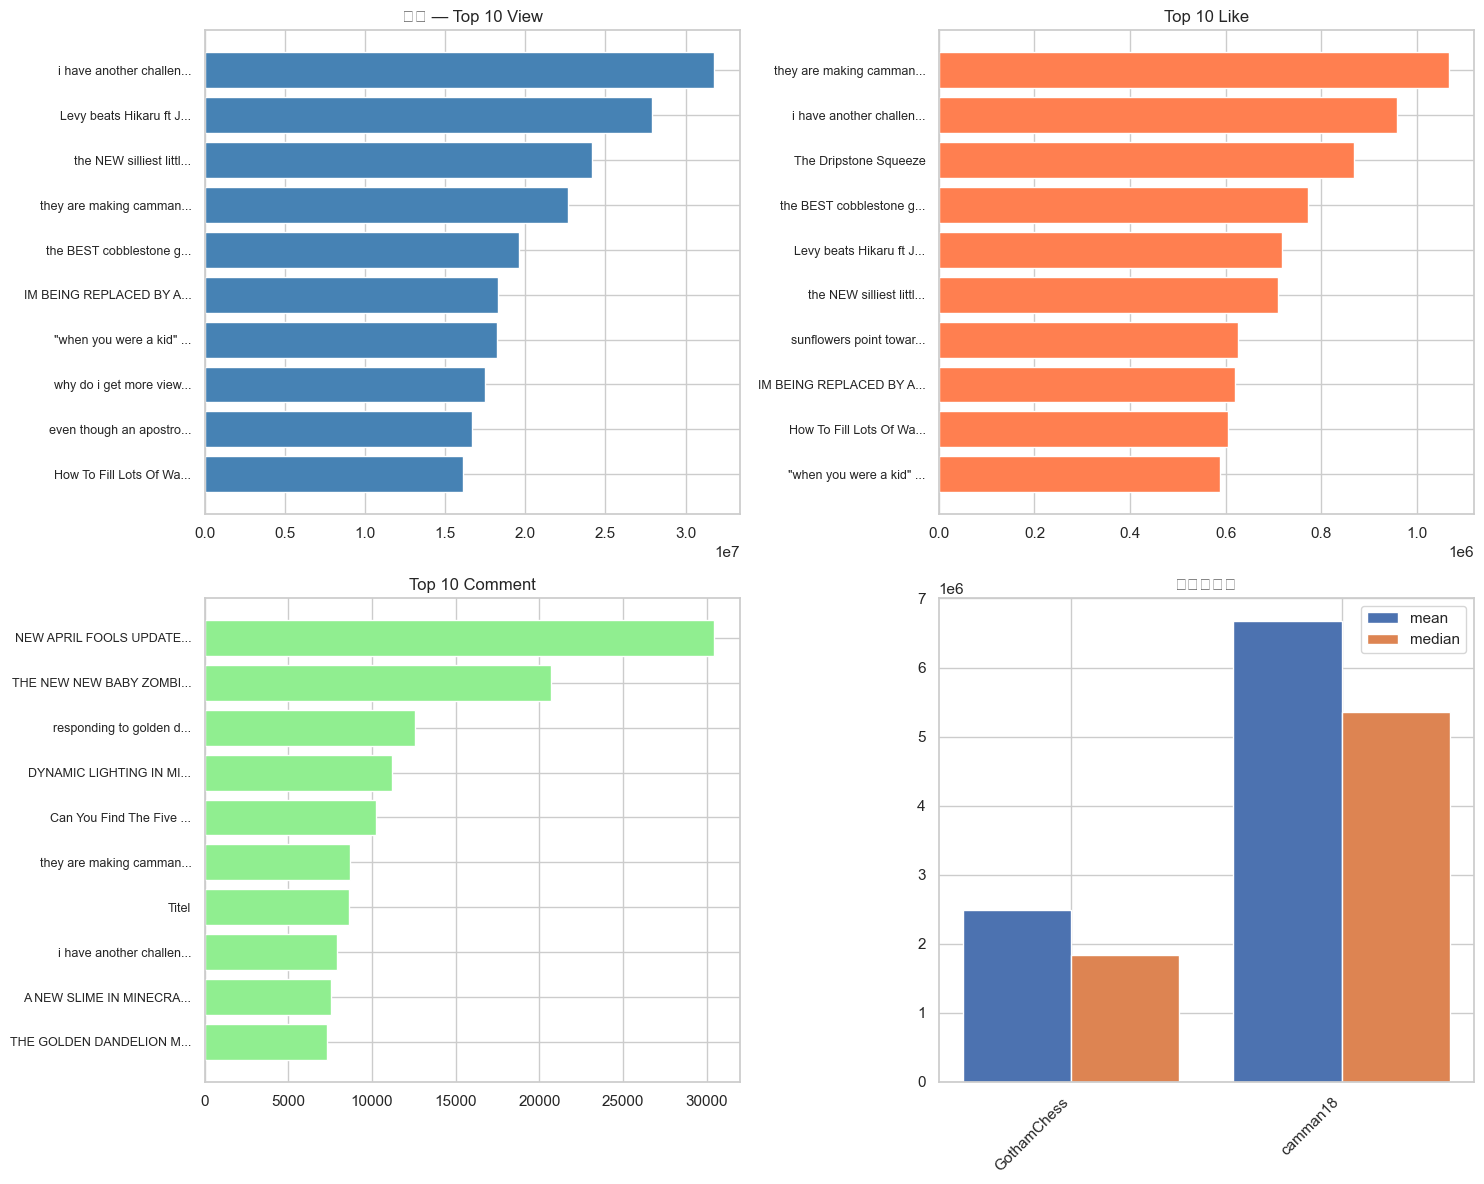

In [12]:
# Top 10 視覺化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

t10v = df_shorts.nlargest(10, 'view_count')
axes[0,0].barh(range(len(t10v)), t10v['view_count'].values, color='steelblue')
axes[0,0].set_yticks(range(len(t10v)))
axes[0,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10v['title']], fontsize=9)
axes[0,0].set_title(f'{CATEGORY_NAME} — Top 10 View'); axes[0,0].invert_yaxis()

t10l = df_shorts.nlargest(10, 'like_count')
axes[0,1].barh(range(len(t10l)), t10l['like_count'].values, color='coral')
axes[0,1].set_yticks(range(len(t10l)))
axes[0,1].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10l['title']], fontsize=9)
axes[0,1].set_title('Top 10 Like'); axes[0,1].invert_yaxis()

t10c = df_shorts.nlargest(10, 'comment_count')
axes[1,0].barh(range(len(t10c)), t10c['comment_count'].values, color='lightgreen')
axes[1,0].set_yticks(range(len(t10c)))
axes[1,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10c['title']], fontsize=9)
axes[1,0].set_title('Top 10 Comment'); axes[1,0].invert_yaxis()

ch_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean','median']).reset_index()
x = range(len(ch_summary))
axes[1,1].bar([i-0.2 for i in x], ch_summary['mean'], 0.4, label='mean')
axes[1,1].bar([i+0.2 for i in x], ch_summary['median'], 0.4, label='median')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(ch_summary['channel_title'], rotation=45, ha='right')
axes[1,1].set_title('頻道觀看數'); axes[1,1].legend()

plt.tight_layout(); plt.show()


## 9. 迴歸：兩條 OLS 線 + channel dummy

In [13]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_reg = df_shorts[['view_count','duration_sec','title_length','tag_count','channel_title']].dropna()
print(f"迴歸樣本數：{len(df_reg)}")

if len(df_reg) >= 10:
    scaler = StandardScaler()
    feats = ['duration_sec','title_length','tag_count']
    dfs = df_reg.copy()
    dfs[feats] = scaler.fit_transform(df_reg[feats])

    m1 = smf.ols('view_count ~ duration_sec + title_length + tag_count', data=dfs).fit()
    m2 = smf.ols('view_count ~ duration_sec + title_length + tag_count + C(channel_title)', data=dfs).fit()
    print("Model 1（無 channel dummy）：")
    print(m1.summary())
    print("\nModel 2（含 channel dummy）：")
    print(m2.summary())
    print(f"\nM1 R²={m1.rsquared:.4f}  Adj R²={m1.rsquared_adj:.4f}")
    print(f"M2 R²={m2.rsquared:.4f}  Adj R²={m2.rsquared_adj:.4f}")

    X = m1.model.exog
    names = m1.model.exog_names
    vif = pd.DataFrame({"Variable": names[1:],
                        "VIF": [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]})
    print("\nVIF：")
    print(vif.to_string(index=False))
else:
    print("樣本太少，跳過迴歸")


迴歸樣本數：308
Model 1（無 channel dummy）：
                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     26.68
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.42e-15
Time:                        14:55:36   Log-Likelihood:                -5121.1
No. Observations:                 308   AIC:                         1.025e+04
Df Residuals:                     304   BIC:                         1.027e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept   

## 10. 散布圖 + 回歸線（依 channel 著色）

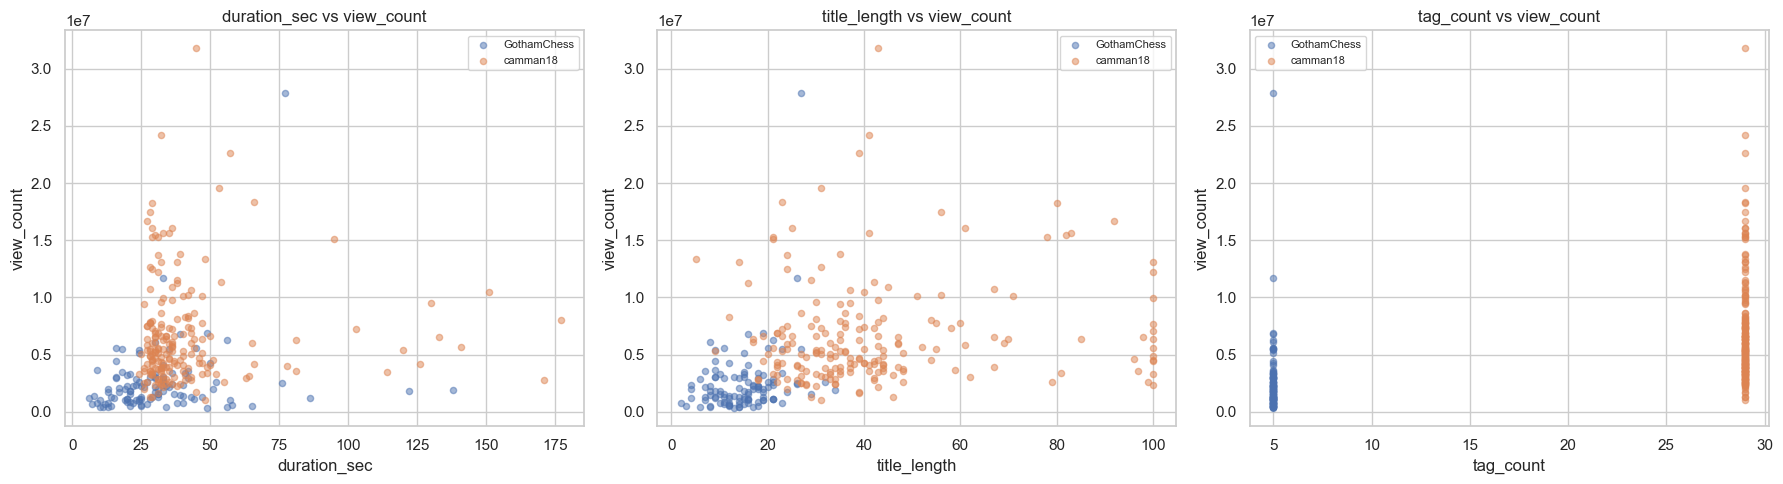

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, x_col in zip(axes, ['duration_sec','title_length','tag_count']):
    for ch, g in df_shorts.groupby('channel_title'):
        ax.scatter(g[x_col], g['view_count'], alpha=0.5, label=ch, s=20)
    ax.set_xlabel(x_col); ax.set_ylabel('view_count')
    ax.set_title(f'{x_col} vs view_count'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 11. 結論

（依分析結果手動撰寫）